# Day 35 - 最终总结 + 知识地图

> 目标: 回顾 35 天旅程, 画出完整的深度学习知识地图
>
> 35 天前你可能连 NumPy 都不熟, 今天你已经懂了从线性回归到扩散模型

---

## 35 天旅程回顾

```
Day 1:  NumPy 是什么?           Day 35: 我该选 CV 还是 NLP?
  ├── 完全新手                        ├── Transformer 手写实现
  ├── "深度学习 = 魔法"               ├── BERT/GPT 的区别
  └── 只会调包                        └── 能自己训练模型了

这不是魔法, 是 35 天一步步走过来的路。
你证明了: 只要每天学一点, 35 天可以走很远。
```

Day 35 - Final Summary & Knowledge Map

35 days completed!



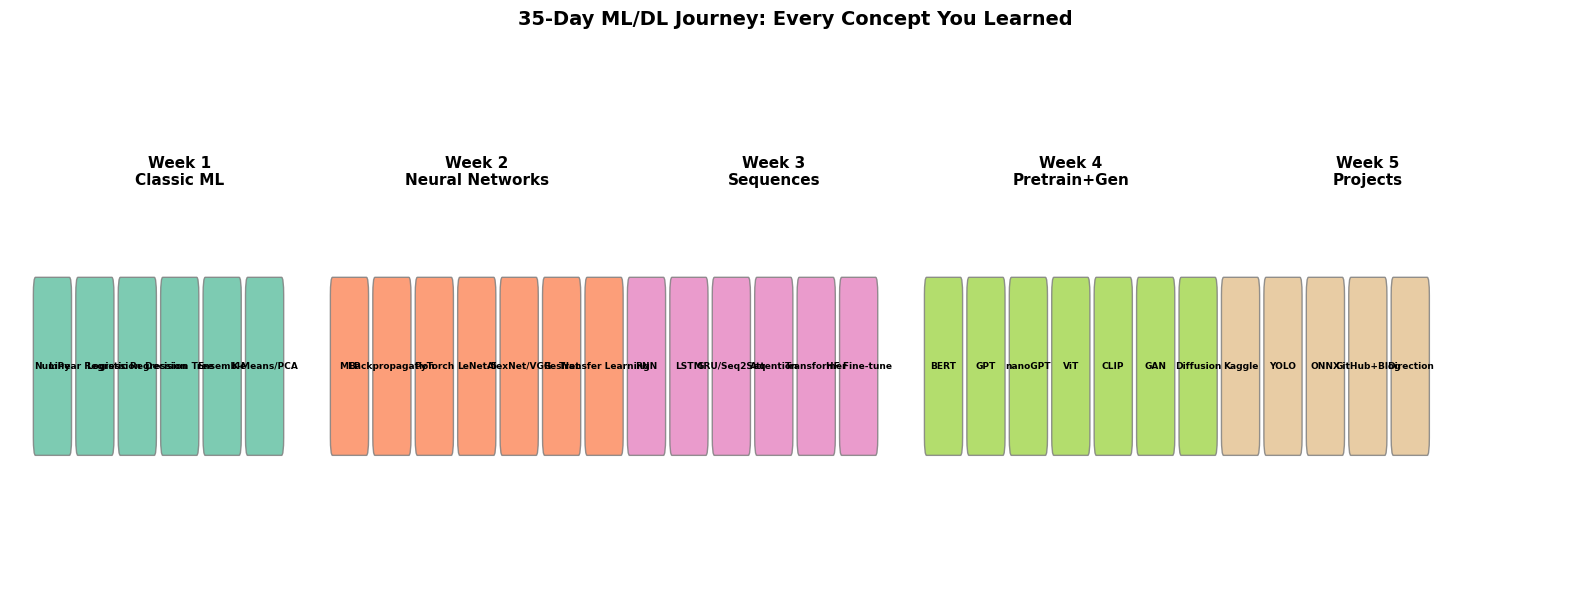

35 天概念全景 —— 每一格都是你学会的知识点


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

print('=' * 40)
print('Day 35 - Final Summary & Knowledge Map')
print('=' * 40)

print()
print('35 days completed!')
print()

w1 = ['NumPy', 'Linear Regression', 'Logistic Regression',
      'Decision Tree', 'Ensemble', 'K-Means/PCA']
w2 = ['MLP', 'Backpropagation', 'PyTorch', 'LeNet-5',
      'AlexNet/VGG', 'ResNet', 'Transfer Learning']
w3 = ['RNN', 'LSTM', 'GRU/Seq2Seq', 'Attention',
      'Transformer', 'HF Fine-tune']
w4 = ['BERT', 'GPT', 'nanoGPT', 'ViT', 'CLIP', 'GAN', 'Diffusion']
w5 = ['Kaggle', 'YOLO', 'ONNX', 'GitHub+Blog', 'Direction']

weeks = [w1, w2, w3, w4, w5]
names = ['Week 1\nClassic ML', 'Week 2\nNeural Networks',
         'Week 3\nSequences', 'Week 4\nPretrain+Gen', 'Week 5\nProjects']

fig, ax = plt.subplots(figsize=(16, 6))
for wi, week in enumerate(weeks):
    for di, day in enumerate(week):
        x = wi * 7 + di
        rect = patches.FancyBboxPatch((x - 0.4, 0.4), 0.8, 0.4,
                                       boxstyle="round,pad=0.05",
                                       facecolor=plt.cm.Set2(wi/5),
                                       edgecolor='gray', alpha=0.85)
        ax.add_patch(rect)
        ax.text(x, 0.6, f'{day}', ha='center', va='center',
                fontsize=6.5, fontweight='bold', rotation=0)
    ax.text(wi * 7 + 3, 1.1, names[wi], ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_xlim(-1, 36)
ax.set_ylim(0, 1.5)
ax.axis('off')
ax.set_title('35-Day ML/DL Journey: Every Concept You Learned',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('day35_journey_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('35 天概念全景 —— 每一格都是你学会的知识点')

---

## 1. 第 1 周回顾: 经典机器学习

> 从零开始, 用 NumPy 手写机器学习算法

In [2]:
# ============================================
# Week 1: Classic ML 回顾
# ============================================

w1_summary = {
    'Day 1': ('NumPy + Pandas', '向量化运算, 广播机制, DataFrame 操作'),
    'Day 2': ('线性回归', '手写梯度下降, MSE 损失, 学习率调度'),
    'Day 3': ('逻辑回归', 'Sigmoid, 交叉熵损失, 决策边界'),
    'Day 4': ('决策树', '基尼系数, 信息增益, 过拟合/剪枝'),
    'Day 5': ('集成学习', '随机森林, XGBoost, Bagging vs Boosting'),
    'Day 6': ('K-Means + PCA', '无监督聚类, 降维, Elbow Method'),
    'Day 7': ('周复习', '六模型大乱斗, 对比报告'),
}

print('Week 1 - 经典机器学习')
print('=' * 50)
for day, (topic, desc) in w1_summary.items():
    print(f'{day:<6} {topic:<20} -> {desc}')
print()

print('核心收获:')
print('  - ML 不是魔法, 是数学: 梯度下降 / 损失函数 / 评估指标')
print('  - 过拟合是头号敌人, 验证集是最好的朋友')
print('  - sklearn 可以让你 5 行代码跑通一个模型')
print('  - 但手写一遍才能真正理解它怎么 work')

Week 1 - 经典机器学习
Day 1  NumPy + Pandas       -> 向量化运算, 广播机制, DataFrame 操作
Day 2  线性回归                 -> 手写梯度下降, MSE 损失, 学习率调度
Day 3  逻辑回归                 -> Sigmoid, 交叉熵损失, 决策边界
Day 4  决策树                  -> 基尼系数, 信息增益, 过拟合/剪枝
Day 5  集成学习                 -> 随机森林, XGBoost, Bagging vs Boosting
Day 6  K-Means + PCA        -> 无监督聚类, 降维, Elbow Method
Day 7  周复习                  -> 六模型大乱斗, 对比报告

核心收获:
  - ML 不是魔法, 是数学: 梯度下降 / 损失函数 / 评估指标
  - 过拟合是头号敌人, 验证集是最好的朋友
  - sklearn 可以让你 5 行代码跑通一个模型
  - 但手写一遍才能真正理解它怎么 work


## 2. 第 2 周回顾: 神经网络

> 从逻辑回归迈入深度学习, 理解神经网络的核心机制

In [3]:
# ============================================
# Week 2: Neural Networks 回顾
# ============================================

w2_summary = {
    'Day 8':  ('MLP', '神经元=逻辑回归+激活, 多层堆叠=非线性'),
    'Day 9':  ('反向传播', '链式法则, 梯度穿过隐藏层, 自动求导'),
    'Day 10': ('PyTorch 入门', 'Tensor, Autograd, nn.Module, DataLoader'),
    'Day 11': ('LeNet-5', '卷积/池化/感受野, CNN 开山之作'),
    'Day 12': ('AlexNet/VGG', '网络加深, ReLU/Dropout, 退化问题出现'),
    'Day 13': ('ResNet', '残差连接 -> 152 层不退化, 梯度直接流过'),
    'Day 14': ('迁移学习', '预训练 ResNet 微调, 冻结/解冻策略'),
}

print('Week 2 - 神经网络')
print('=' * 50)
for day, (topic, desc) in w2_summary.items():
    print(f'{day:<6} {topic:<20} -> {desc}')
print()

print('核心收获:')
print('  - 没有激活函数, 多层=一层 (线性复合还是线性)')
print('  - 梯度消失=连乘小于 1 的数, 梯度爆炸=连乘大于 1')
print('  - 残差连接让梯度有一条"高速公路"')
print('  - 迁移学习: 别人训练了 4 天, 你微调 1 分钟')

Week 2 - 神经网络
Day 8  MLP                  -> 神经元=逻辑回归+激活, 多层堆叠=非线性
Day 9  反向传播                 -> 链式法则, 梯度穿过隐藏层, 自动求导
Day 10 PyTorch 入门           -> Tensor, Autograd, nn.Module, DataLoader
Day 11 LeNet-5              -> 卷积/池化/感受野, CNN 开山之作
Day 12 AlexNet/VGG          -> 网络加深, ReLU/Dropout, 退化问题出现
Day 13 ResNet               -> 残差连接 -> 152 层不退化, 梯度直接流过
Day 14 迁移学习                 -> 预训练 ResNet 微调, 冻结/解冻策略

核心收获:
  - 没有激活函数, 多层=一层 (线性复合还是线性)
  - 梯度消失=连乘小于 1 的数, 梯度爆炸=连乘大于 1
  - 残差连接让梯度有一条"高速公路"
  - 迁移学习: 别人训练了 4 天, 你微调 1 分钟


## 3. 第 3 周回顾: 序列模型与 Transformer

> 从 RNN 到 Transformer, 理解序列建模的完整演化

In [5]:
# ============================================
# Week 3: Sequences & Transformer 回顾
# ============================================

w3_summary = {
    'Day 15': ('RNN', '隐藏状态 h_t = tanh(W·x_t + U·h_{t-1}), BPTT, 梯度消失'),
    'Day 16': ('LSTM', '遗忘/输入/输出三个门, 细胞状态 C_t 保存长程记忆'),
    'Day 17': ('GRU+Seq2Seq', '更新门+重置门 (LSTM 简化版), 编码器-解码器'),
    'Day 18': ('Attention', 'Bahdanau 加性注意力, 解码器看所有编码器状态'),
    'Day 19': ('Transformer', 'Self-Attention, Multi-Head, 位置编码, 完整 Encoder'),
    'Day 20': ('实战微调', 'HuggingFace DistilBERT, 文本分类 100%'),
    'Day 21': ('周复习', 'RNN -> LSTM -> GRU -> Attention -> Transformer 演化对比'),
}

print('Week 3 - 序列模型与 Transformer')
print('=' * 50)
for day, (topic, desc) in w3_summary.items():
    print(f'{day:<6} {topic:<20} -> {desc}')
print()

print('核心收获:')
print('  - RNN 的问题: 顺序计算(慢) + 梯度消失(记不住)')
print('  - LSTM 用门结构让梯度可以无损流过')
print('  - Attention 让解码器"看"所有输入, 解决信息瓶颈')
print('  - Transformer 用 Self-Attention 彻底抛弃 RNN')
print('  - 这是 NLP 领域最重要的技术演进路线')

Week 3 - 序列模型与 Transformer
Day 15 RNN                  -> 隐藏状态 h_t = tanh(W·x_t + U·h_{t-1}), BPTT, 梯度消失
Day 16 LSTM                 -> 遗忘/输入/输出三个门, 细胞状态 C_t 保存长程记忆
Day 17 GRU+Seq2Seq          -> 更新门+重置门 (LSTM 简化版), 编码器-解码器
Day 18 Attention            -> Bahdanau 加性注意力, 解码器看所有编码器状态
Day 19 Transformer          -> Self-Attention, Multi-Head, 位置编码, 完整 Encoder
Day 20 实战微调                 -> HuggingFace DistilBERT, 文本分类 100%
Day 21 周复习                  -> RNN -> LSTM -> GRU -> Attention -> Transformer 演化对比

核心收获:
  - RNN 的问题: 顺序计算(慢) + 梯度消失(记不住)
  - LSTM 用门结构让梯度可以无损流过
  - Attention 让解码器"看"所有输入, 解决信息瓶颈
  - Transformer 用 Self-Attention 彻底抛弃 RNN
  - 这是 NLP 领域最重要的技术演进路线


## 4. 第 4 周回顾: 预训练与生成模型

> 从 BERT 到 Stable Diffusion, 走进 AI 的最前沿

In [6]:
# ============================================
# Week 4: Pretraining & Generation 回顾
# ============================================

w4_summary = {
    'Day 22': ('BERT', 'MLM 填空预训练 + 双向 Encoder, 理解任务 SOTA'),
    'Day 23': ('GPT', '自回归 + 下一个词预测, 生成任务的开端'),
    'Day 24': ('nanoGPT', 'Karpathy 从零写 GPT, 200 行代码理解大模型'),
    'Day 25': ('ViT', 'Transformer 做图像分类, 图像切成 Patch 当序列'),
    'Day 26': ('CLIP', '图文双编码器, 对比学习, 4 亿图文对'),
    'Day 27': ('GAN', '生成器 vs 判别器, 对抗训练, 模式崩溃'),
    'Day 28': ('Diffusion', '逐步加噪 -> 逐步去噪, 潜空间 + 文本条件'),
}

print('Week 4 - 预训练与生成模型')
print('=' * 50)
for day, (topic, desc) in w4_summary.items():
    print(f'{day:<6} {topic:<20} -> {desc}')
print()

print('核心收获:')
print('  - 预训练 + 微调是深度学习最强大的范式')
print('  - BERT=编码器(理解), GPT=解码器(生成)')
print('  - ViT 证明 Transformer 可以吃掉 CNN')
print('  - CLIP 让图文理解统一框架')
print('  - GAN 对抗训练 vs 扩散模型逐步去噪')
print('  - Stable Diffusion = 扩散 + 潜空间 + 文本条件')

Week 4 - 预训练与生成模型
Day 22 BERT                 -> MLM 填空预训练 + 双向 Encoder, 理解任务 SOTA
Day 23 GPT                  -> 自回归 + 下一个词预测, 生成任务的开端
Day 24 nanoGPT              -> Karpathy 从零写 GPT, 200 行代码理解大模型
Day 25 ViT                  -> Transformer 做图像分类, 图像切成 Patch 当序列
Day 26 CLIP                 -> 图文双编码器, 对比学习, 4 亿图文对
Day 27 GAN                  -> 生成器 vs 判别器, 对抗训练, 模式崩溃
Day 28 Diffusion            -> 逐步加噪 -> 逐步去噪, 潜空间 + 文本条件

核心收获:
  - 预训练 + 微调是深度学习最强大的范式
  - BERT=编码器(理解), GPT=解码器(生成)
  - ViT 证明 Transformer 可以吃掉 CNN
  - CLIP 让图文理解统一框架
  - GAN 对抗训练 vs 扩散模型逐步去噪
  - Stable Diffusion = 扩散 + 潜空间 + 文本条件


## 5. 第 5 周回顾: 实战与收尾

> 把前面学的知识用到实战中, 并学会展示自己

In [7]:
# ============================================
# Week 5: Projects & Wrap-up 回顾
# ============================================

w5_summary = {
    'Day 29': ('Kaggle 表格数据', 'EDA -> 特征工程 -> 模型集成 -> 提交'),
    'Day 30': ('Kaggle NLP', 'TF-IDF -> LSTM -> 多模型对比 -> 提交'),
    'Day 31': ('YOLO 检测', '网格+锚框 -> NMS -> 预训练模型调用'),
    'Day 32': ('ONNX 部署', 'PyTorch -> ONNX -> ONNX Runtime 推理'),
    'Day 33': ('GitHub+博客', 'Profile README -> 仓库整理 -> 技术博客'),
    'Day 34': ('方向选择', 'CV / NLP / 多模态 / RL 对比与选择'),
    'Day 35': ('最终总结', '知识地图 + 回顾 + 下一步'),
}

print('Week 5 - 实战与收尾')
print('=' * 50)
for day, (topic, desc) in w5_summary.items():
    print(f'{day:<6} {topic:<20} -> {desc}')
print()

print('核心收获:')
print('  - Kaggle = ML 界的"刷题", EDA 决定上限')
print('  - YOLO 让你知道目标检测不是黑魔法')
print('  - ONNX 让模型能在任何平台运行')
print('  - GitHub + 博客 = 你的技术名片')

Week 5 - 实战与收尾
Day 29 Kaggle 表格数据          -> EDA -> 特征工程 -> 模型集成 -> 提交
Day 30 Kaggle NLP           -> TF-IDF -> LSTM -> 多模型对比 -> 提交
Day 31 YOLO 检测              -> 网格+锚框 -> NMS -> 预训练模型调用
Day 32 ONNX 部署              -> PyTorch -> ONNX -> ONNX Runtime 推理
Day 33 GitHub+博客            -> Profile README -> 仓库整理 -> 技术博客
Day 34 方向选择                 -> CV / NLP / 多模态 / RL 对比与选择
Day 35 最终总结                 -> 知识地图 + 回顾 + 下一步

核心收获:
  - Kaggle = ML 界的"刷题", EDA 决定上限
  - YOLO 让你知道目标检测不是黑魔法
  - ONNX 让模型能在任何平台运行
  - GitHub + 博客 = 你的技术名片


## 6. 知识地图 — 把所有概念串起来

> 这是 35 天最核心的一张图, 保存它

In [8]:
# ============================================
# 完整知识地图: 35 天概念关系图
# ============================================

print('=' * 80)
print('                       35 天 ML/DL 知识地图')
print('=' * 80)
print()

print('数学基础')
print('  +-- NumPy (向量化/广播) --------------- Day 1')
print('  +-- 梯度下降 (MSE/交叉熵) ------------ Day 2-3')
print('  +-- 链式法则 (反向传播) -------------- Day 9')
print()

print('经典机器学习')
print('  +-- 线性/逻辑回归 -------------------- Day 2-3')
print('  +-- 决策树 -> 随机森林/XGBoost ------- Day 4-5')
print('  +-- K-Means + PCA -------------------- Day 6')
print('  |')
print('  +-- (从这里进入深度学习)')
print()

print('深度学习基础')
print('  +-- MLP (神经元 + 激活函数) ---------- Day 8')
print('  +-- 反向传播 (链式法则) ------------ Day 9')
print('  +-- PyTorch (Tensor + Autograd) ------ Day 10')
print('  +-- CNN (卷积/池化) ------------------ Day 11-13')
print('  +-- ResNet (残差连接) --------------- Day 13')
print('  +-- 迁移学习 (微调) ------------------ Day 14')
print('  |')
print('  +-- (分三条路)')
print()

print('CV 路线                         NLP 路线                      生成路线')
print('  ViT (图像即序列) Day 25        RNN -> LSTM -> GRU              GAN (对抗) Day 27')
print('  YOLO (检测) Day 31                Day 15-17                   Diffusion Day 28')
print('                                Attention Day 18')
print('                                Transformer Day 19')
print('                                BERT (理解) Day 22')
print('                                GPT (生成) Day 23')
print('                                nanoGPT Day 24')
print('                                |')
print('                                +-- 多模态')
print('                                   CLIP (图文) Day 26')
print()

print('实战部署')
print('  +-- Kaggle (EDA + 调参) ------------- Day 29-30')
print('  +-- YOLO 检测器 --------------------- Day 31')
print('  +-- ONNX 导出 + 推理 ---------------- Day 32')
print('  +-- GitHub + 技术博客 --------------- Day 33')
print('  +-- 方向选择 ------------------------- Day 34')
print('  +-- 最终总结 ------------------------- Day 35')
print()

print('=' * 80)
print('  你的技能树 (Skill Tree):')
print('    Level 1: Python + NumPy (数据处理)')
print('    Level 2: sklearn (经典 ML 算法)')
print('    Level 3: PyTorch (深度学习框架)')
print('    Level 4: CNN/RNN/Transformer (模型架构)')
print('    Level 5: BERT/GPT/Diffusion (预训练/生成)')
print('    Level 6: Kaggle/YOLO/ONNX (实战部署)')
print('=' * 80)

                       35 天 ML/DL 知识地图

数学基础
  +-- NumPy (向量化/广播) --------------- Day 1
  +-- 梯度下降 (MSE/交叉熵) ------------ Day 2-3
  +-- 链式法则 (反向传播) -------------- Day 9

经典机器学习
  +-- 线性/逻辑回归 -------------------- Day 2-3
  +-- 决策树 -> 随机森林/XGBoost ------- Day 4-5
  +-- K-Means + PCA -------------------- Day 6
  |
  +-- (从这里进入深度学习)

深度学习基础
  +-- MLP (神经元 + 激活函数) ---------- Day 8
  +-- 反向传播 (链式法则) ------------ Day 9
  +-- PyTorch (Tensor + Autograd) ------ Day 10
  +-- CNN (卷积/池化) ------------------ Day 11-13
  +-- ResNet (残差连接) --------------- Day 13
  +-- 迁移学习 (微调) ------------------ Day 14
  |
  +-- (分三条路)

CV 路线                         NLP 路线                      生成路线
  ViT (图像即序列) Day 25        RNN -> LSTM -> GRU              GAN (对抗) Day 27
  YOLO (检测) Day 31                Day 15-17                   Diffusion Day 28
                                Attention Day 18
                                Transformer Day 19
                                BERT (理解) Day 22
                   

## 7. 技能树可视化

> 你的深度学习技能树长什么样?

D:\hyy\Temp\ipykernel_27204\3028570018.py:47: UserWarning: Glyph 32463 (\N{CJK UNIFIED IDEOGRAPH-7ECF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_27204\3028570018.py:47: UserWarning: Glyph 20856 (\N{CJK UNIFIED IDEOGRAPH-5178}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_27204\3028570018.py:47: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_27204\3028570018.py:47: UserWarning: Glyph 30784 (\N{CJK UNIFIED IDEOGRAPH-7840}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_27204\3028570018.py:47: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_27204\3028570018.py:47: UserWarning: Glyph 25112 (\N{CJK UNIFIED IDEOGRAPH-6218}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_27204\3028570018.py:47: 

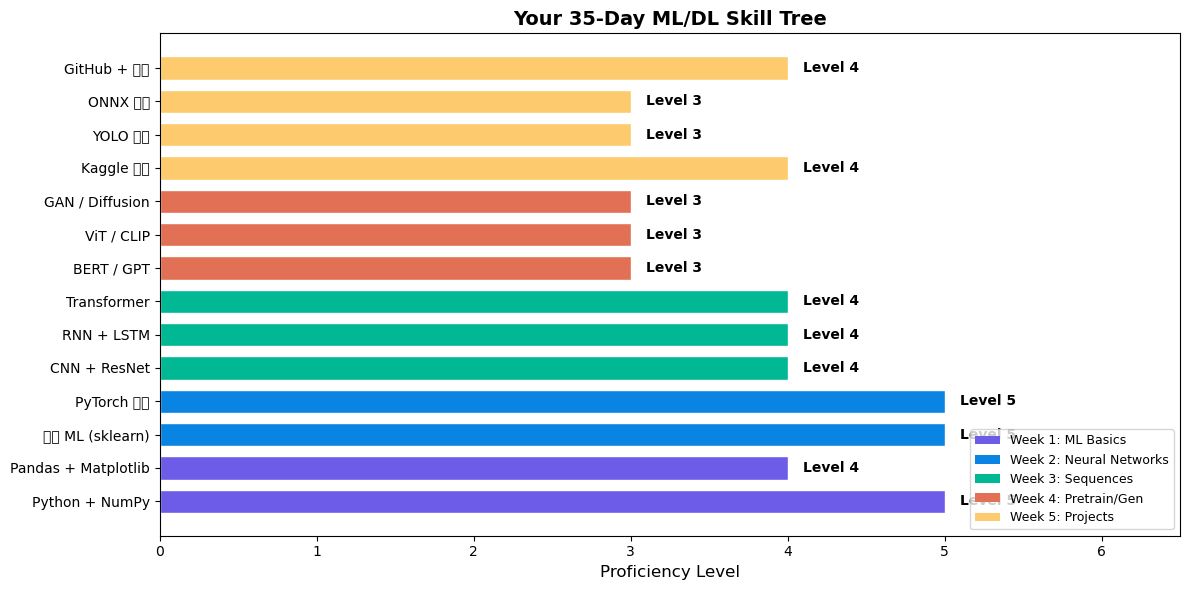

你的技能树 (Level 1-5):
  Level 1: 了解概念
  Level 2: 能读懂代码
  Level 3: 能自己写
  Level 4: 能改/调优
  Level 5: 能教别人

大部分技能在 Level 3-4, 选一个方向继续深入!


In [9]:
# ============================================
# 技能树可视化 (横向柱状图)
# ============================================

levels = [
    ('Python + NumPy', 5, '#6c5ce7'),
    ('Pandas + Matplotlib', 4, '#6c5ce7'),
    ('经典 ML (sklearn)', 5, '#0984e3'),
    ('PyTorch 基础', 5, '#0984e3'),
    ('CNN + ResNet', 4, '#00b894'),
    ('RNN + LSTM', 4, '#00b894'),
    ('Transformer', 4, '#00b894'),
    ('BERT / GPT', 3, '#e17055'),
    ('ViT / CLIP', 3, '#e17055'),
    ('GAN / Diffusion', 3, '#e17055'),
    ('Kaggle 实战', 4, '#fdcb6e'),
    ('YOLO 检测', 3, '#fdcb6e'),
    ('ONNX 部署', 3, '#fdcb6e'),
    ('GitHub + 博客', 4, '#fdcb6e'),
]

skills = [l[0] for l in levels]
scores = [l[1] for l in levels]
colors = [l[2] for l in levels]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(skills, scores, color=colors, edgecolor='white', height=0.7)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'Level {score}', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, 6.5)
ax.set_xlabel('Proficiency Level', fontsize=12)
ax.set_title('Your 35-Day ML/DL Skill Tree', fontsize=14, fontweight='bold')

# Legend
legend_elements = [
    plt.Rectangle((0,0), 1, 1, facecolor='#6c5ce7', label='Week 1: ML Basics'),
    plt.Rectangle((0,0), 1, 1, facecolor='#0984e3', label='Week 2: Neural Networks'),
    plt.Rectangle((0,0), 1, 1, facecolor='#00b894', label='Week 3: Sequences'),
    plt.Rectangle((0,0), 1, 1, facecolor='#e17055', label='Week 4: Pretrain/Gen'),
    plt.Rectangle((0,0), 1, 1, facecolor='#fdcb6e', label='Week 5: Projects'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('day35_skill_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print('你的技能树 (Level 1-5):')
print('  Level 1: 了解概念')
print('  Level 2: 能读懂代码')
print('  Level 3: 能自己写')
print('  Level 4: 能改/调优')
print('  Level 5: 能教别人')
print()
print('大部分技能在 Level 3-4, 选一个方向继续深入!')

## 8. 你现在能做什么?

> 35 天后, 这些你已经可以独立完成了

In [10]:
# ============================================
# 你现在能做的事
# ============================================

can_do = [
    '用 NumPy 做向量化运算, 处理表格数据',
    '用 sklearn 跑 5 种以上 ML 模型并调参',
    '用 PyTorch 搭 CNN/RNN/Transformer',
    '理解反向传播, 知道梯度从哪来到哪去',
    '用 HuggingFace 加载预训练模型做微调',
    '手写 Self-Attention, 理解 Transformer 核心',
    '区分 BERT (理解) 和 GPT (生成) 的区别',
    '用 YOLO 做目标检测, 理解 NMS',
    '把模型导出 ONNX, 跨平台部署',
    '写一个漂亮的 GitHub README',
    '写一篇技术博客, 讲清楚一个 AI 概念',
    '选一个方向, 知道怎么继续深入',
]

print('你现在能做的事:')
print()
for i, item in enumerate(can_do, 1):
    print(f'  {i:>2}. {item}')
print()

print('对比 35 天前:')
print('  35 天前: "深度学习 = 黑魔法 / 调包"')
print('  35 天后: "深度学习 = 数学 + 代码 + 实验"')
print()
print('最大的变化不是知识量, 而是:')
print('  你知道了"我不知道什么" -> 你能自学任何新方向')

你现在能做的事:

   1. 用 NumPy 做向量化运算, 处理表格数据
   2. 用 sklearn 跑 5 种以上 ML 模型并调参
   3. 用 PyTorch 搭 CNN/RNN/Transformer
   4. 理解反向传播, 知道梯度从哪来到哪去
   5. 用 HuggingFace 加载预训练模型做微调
   6. 手写 Self-Attention, 理解 Transformer 核心
   7. 区分 BERT (理解) 和 GPT (生成) 的区别
   8. 用 YOLO 做目标检测, 理解 NMS
   9. 把模型导出 ONNX, 跨平台部署
  10. 写一个漂亮的 GitHub README
  11. 写一篇技术博客, 讲清楚一个 AI 概念
  12. 选一个方向, 知道怎么继续深入

对比 35 天前:
  35 天前: "深度学习 = 黑魔法 / 调包"
  35 天后: "深度学习 = 数学 + 代码 + 实验"

最大的变化不是知识量, 而是:
  你知道了"我不知道什么" -> 你能自学任何新方向


## 9. 下一步怎么走?

> 35 天结束, 学习永远不会结束

In [11]:
# ============================================
# 下一步建议
# ============================================

next_steps = [
    ('短期 (1-2 周)', [
        '重新看你最感兴趣的那个 Day, 这次不看代码自己写',
        '选一个方向 (第 34 天), 看对应公开课的前 3 课',
        '给 35 天仓库写一个总览 README',
    ]),
    ('中期 (1-3 个月)', [
        '精读 5-10 篇该方向经典论文',
        '复现 2-3 个核心项目',
        '参加一个 Kaggle 竞赛',
        '写 2-3 篇技术博客',
    ]),
    ('长期 (3-12 个月)', [
        '做一个自己的项目 (解决实际问题)',
        '给开源项目贡献 PR',
        '找实习 / 换工作',
        '持续关注前沿进展 (arxiv / Twitter)',
    ]),
]

for period, steps in next_steps:
    print(f'  {period}')
    for s in steps:
        print(f'    -> {s}')
    print()

print('推荐学习路径 (按方向):')
print()
print('  CV:  CS231n -> MMDetection -> Kaggle CV')
print('  NLP: CS224n -> HuggingFace -> LLM 应用')
print('  多模态: CLIP -> Diffusers -> LLaVA')
print('  RL:  David Silver RL -> Spinning Up -> RLHF')
print()
print('通用:')
print('  刷题: LeetCode (Python) + 牛客网 (AI 八股)')
print('  读论文: arxiv.org + paperswithcode.com')
print('  代码: huggingface.co/papers + GitHub Trending')

  短期 (1-2 周)
    -> 重新看你最感兴趣的那个 Day, 这次不看代码自己写
    -> 选一个方向 (第 34 天), 看对应公开课的前 3 课
    -> 给 35 天仓库写一个总览 README

  中期 (1-3 个月)
    -> 精读 5-10 篇该方向经典论文
    -> 复现 2-3 个核心项目
    -> 参加一个 Kaggle 竞赛
    -> 写 2-3 篇技术博客

  长期 (3-12 个月)
    -> 做一个自己的项目 (解决实际问题)
    -> 给开源项目贡献 PR
    -> 找实习 / 换工作
    -> 持续关注前沿进展 (arxiv / Twitter)

推荐学习路径 (按方向):

  CV:  CS231n -> MMDetection -> Kaggle CV
  NLP: CS224n -> HuggingFace -> LLM 应用
  多模态: CLIP -> Diffusers -> LLaVA
  RL:  David Silver RL -> Spinning Up -> RLHF

通用:
  刷题: LeetCode (Python) + 牛客网 (AI 八股)
  读论文: arxiv.org + paperswithcode.com
  代码: huggingface.co/papers + GitHub Trending


## 10. 最后的话

> 35 天结束了, 但你的 AI 之旅才刚刚开始

In [12]:
# ============================================
# 最后的祝福
# ============================================

final_words = '''
\u250C" 35 天前你说 "我想学深度学习"
\u2502  35 天后你可以说 "我学会了"
\u2502
\u2502  你走过的路:
\u2502    Day 1-7:   经典 ML       -- 算法基础
\u2502    Day 8-14:  神经网络      -- 深度学习入门
\u2502    Day 15-21: 序列模型      -- Transformer
\u2502    Day 22-28: 预训练/生成   -- BERT/GPT/Diffusion
\u2502    Day 29-35: 实战收尾      -- Kaggle/YOLO/GitHub
\u2502
\u2502  35 天, 35 个知识点, 35 份代码
\u2502  从 NumPy 的第一行代码, 到扩散模型的完整实现
\u2502  从"什么是张量"到"我该选 CV 还是 NLP"
\u2502
\u2502  最重要的不是学会了多少,
\u2502  而是你证明了你有能力学会任何东西。
\u2502
\u2502  继续前进。
\u2518
'''

print(final_words)

print()
for i in range(3):
    print('  ' + '*' * 40)
print()
print('  谢谢这 35 天的陪伴!')
print('  接下来, 看你的了。')


┌" 35 天前你说 "我想学深度学习"
│  35 天后你可以说 "我学会了"
│
│  你走过的路:
│    Day 1-7:   经典 ML       -- 算法基础
│    Day 8-14:  神经网络      -- 深度学习入门
│    Day 15-21: 序列模型      -- Transformer
│    Day 22-28: 预训练/生成   -- BERT/GPT/Diffusion
│    Day 29-35: 实战收尾      -- Kaggle/YOLO/GitHub
│
│  35 天, 35 个知识点, 35 份代码
│  从 NumPy 的第一行代码, 到扩散模型的完整实现
│  从"什么是张量"到"我该选 CV 还是 NLP"
│
│  最重要的不是学会了多少,
│  而是你证明了你有能力学会任何东西。
│
│  继续前进。
┘


  ****************************************
  ****************************************
  ****************************************

  谢谢这 35 天的陪伴!
  接下来, 看你的了。


---

## 35 天技能检核表

> 每项你能做到吗? 做到的打 ✅, 做不到的回头复习

| Day | 内容 | 核心技能 | 掌握? |
|:---:|:----|:--------|:----:|
| 1 | NumPy + Pandas | 向量化、广播、DataFrame | ⬜ |
| 2 | 线性回归 | 手写梯度下降, MSE 损失 | ⬜ |
| 3 | 逻辑回归 | Sigmoid, 交叉熵, 决策边界 | ⬜ |
| 4 | 决策树 | 基尼系数, 信息增益 | ⬜ |
| 5 | 集成学习 | 随机森林 vs XGBoost | ⬜ |
| 6 | K-Means + PCA | 聚类, 降维, Elbow Method | ⬜ |
| 7 | 周复习 | 六模型对比 | ⬜ |
| 8 | MLP | 激活函数, 神经元堆叠 | ⬜ |
| 9 | 反向传播 | 链式法则, 梯度计算 | ⬜ |
| 10 | PyTorch | Tensor, nn.Module, DataLoader | ⬜ |
| 11 | LeNet-5 | 卷积/池化, 感受野 | ⬜ |
| 12 | AlexNet/VGG | 网络加深, 退化问题 | ⬜ |
| 13 | ResNet | 残差连接, 梯度流动 | ⬜ |
| 14 | 迁移学习 | 预训练微调, 冻结/解冻 | ⬜ |
| 15 | RNN | 隐藏状态, BPTT, 梯度消失 | ⬜ |
| 16 | LSTM | 遗忘/输入/输出门 | ⬜ |
| 17 | GRU + Seq2Seq | 更新门/重置门, 编码器-解码器 | ⬜ |
| 18 | Attention | Bahdanau 注意力, 信息瓶颈 | ⬜ |
| 19 | Transformer | Self-Attention, Multi-Head, 位置编码 | ⬜ |
| 20 | Transformer 实战 | HuggingFace 微调 | ⬜ |
| 21 | 周复习 | 六种模型演化对比 | ⬜ |
| 22 | BERT | MLM, 双向编码 | ⬜ |
| 23 | GPT | 自回归, 下一个词预测 | ⬜ |
| 24 | nanoGPT | 从零写 GPT | ⬜ |
| 25 | ViT | Transformer 做图像 | ⬜ |
| 26 | CLIP | 图文对比学习 | ⬜ |
| 27 | GAN | 生成器 vs 判别器 | ⬜ |
| 28 | Diffusion | 加噪 -> 去噪, 潜空间 | ⬜ |
| 29 | Kaggle 表格 | EDA, 特征工程, 调参 | ⬜ |
| 30 | Kaggle NLP | TF-IDF, LSTM 文本分类 | ⬜ |
| 31 | YOLO | 网格/锚框, NMS, 目标检测 | ⬜ |
| 32 | ONNX 部署 | PyTorch -> ONNX -> 推理 | ⬜ |
| 33 | GitHub + 博客 | Profile README, 技术博客 | ⬜ |
| 34 | 方向选择 | CV/NLP/多模态/RL | ⬜ |
| 35 | 最终总结 | 知识地图, 回顾 | ✅ |

---

## 知识地图速查

```
数学基础
  +-- NumPy / 梯度下降 / 链式法则
  |
经典 ML
  +-- 线性/逻辑回归 -> 决策树 -> 集成学习 -> K-Means/PCA
  |
神经网络
  +-- MLP -> CNN (LeNet/AlexNet/ResNet) -> 迁移学习
  |
序列模型
  +-- RNN -> LSTM -> GRU -> Attention -> Transformer
  |
预训练模型
  +-- BERT (理解) -> GPT (生成) -> nanoGPT
  +-- ViT (图像) -> CLIP (图文) -> GAN/Diffusion (生成)
  |
实战
  +-- Kaggle -> YOLO -> ONNX -> GitHub+Blog
```

---

## 写在最后

```
  35 天前, 你打开第一天 notebook, 敲下第一行 import numpy as np
  35 天后, 你看到了这里。

  你学会了:
    - 5 个星期, 35 个主题
    - 从 NumPy 到 Stable Diffusion
    - 从"什么是过拟合"到"我该选 CV 还是 NLP"
    - 从照抄代码到能自己改模型

  送给你三句话:
    1. "教是最好的学" — 写博客, 教别人, 你会理解得更深
    2. "不要停止学习" — AI 领域日新月异, 但基础永远不变
    3. "你已经开始了" — 最难的是第一天, 你已经走了 35 天

  GitHub: 别忘了把你的代码推到远程仓库
  博客:   写一篇 35 天学习总结, 你会惊讶自己走了多远
  下一步: 选一个方向, 继续前进。

  再见, 35 天的你。
  你好, 未来的 AI 工程师。
```

![Journey Complete](https://media.giphy.com/media/3o7abKhOpu0NwenH3O/giphy.gif)

---

**全文完. 感谢 35 天的陪伴.** 🎉